# CA3

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import KBinsDiscretizer


### Reading data

In [2]:
data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

### Data exploration and visualisation

In [3]:
data

,Length (cm),Width (cm),Weight (g),Pericarp Thickness (mm),Seed Count,Capsaicin Content,Vitamin C Content (mg),Sugar Content,Moisture Content,Firmness,color,Harvest Time,Average Daily Temperature During Growth (celcius),Average Temperature During Storage (celcius),Scoville Heat Units (SHU)
0,17.37,5.42,94.30,4.90,193.93,3.21,173.59,6.15,88.59,3.40,red,Midday,8.68,5-6,0.00
1,27.78,4.75,262.71,6.56,186.29,8.19,100.41,2.36,111.20,5.45,green,Midday,22.44,NaN,0.00
2,6.17,3.51,66.72,7.96,298.81,4.69,125.91,6.75,72.98,2.77,red,Midday,24.99,NaN,455995.06
3,6.12,6.07,51.24,4.57,39.36,2.76,143.54,5.93,63.93,1.62,yellow,Midday,13.05,NaN,0.00
4,28.58,4.84,166.51,3.07,194.07,7.01,193.76,2.85,88.19,3.99,red,Midday,27.08,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.67,6.51,19.00,2.87,1.53,0.63,9.02,0.63,95.54,4.86,yellow,Evening,16.57,NaN,88266.90
996,17.17,9.25,150.86,1.41,386.87,2.27,268.93,2.21,131.71,2.59,yellow,Morning,22.39,NaN,0.00
997,14.16,6.87,124.72,1.97,202.83,3.31,203.84,2.90,114.42,3.17,yellow,Evening,15.84,7-8,0.00
998,3.71,7.12,29.53,1.05,115.61,9.80,45.95,2.39,97.70,4.01,green,Evening,16.05,NaN,188390.86


### Data cleaning

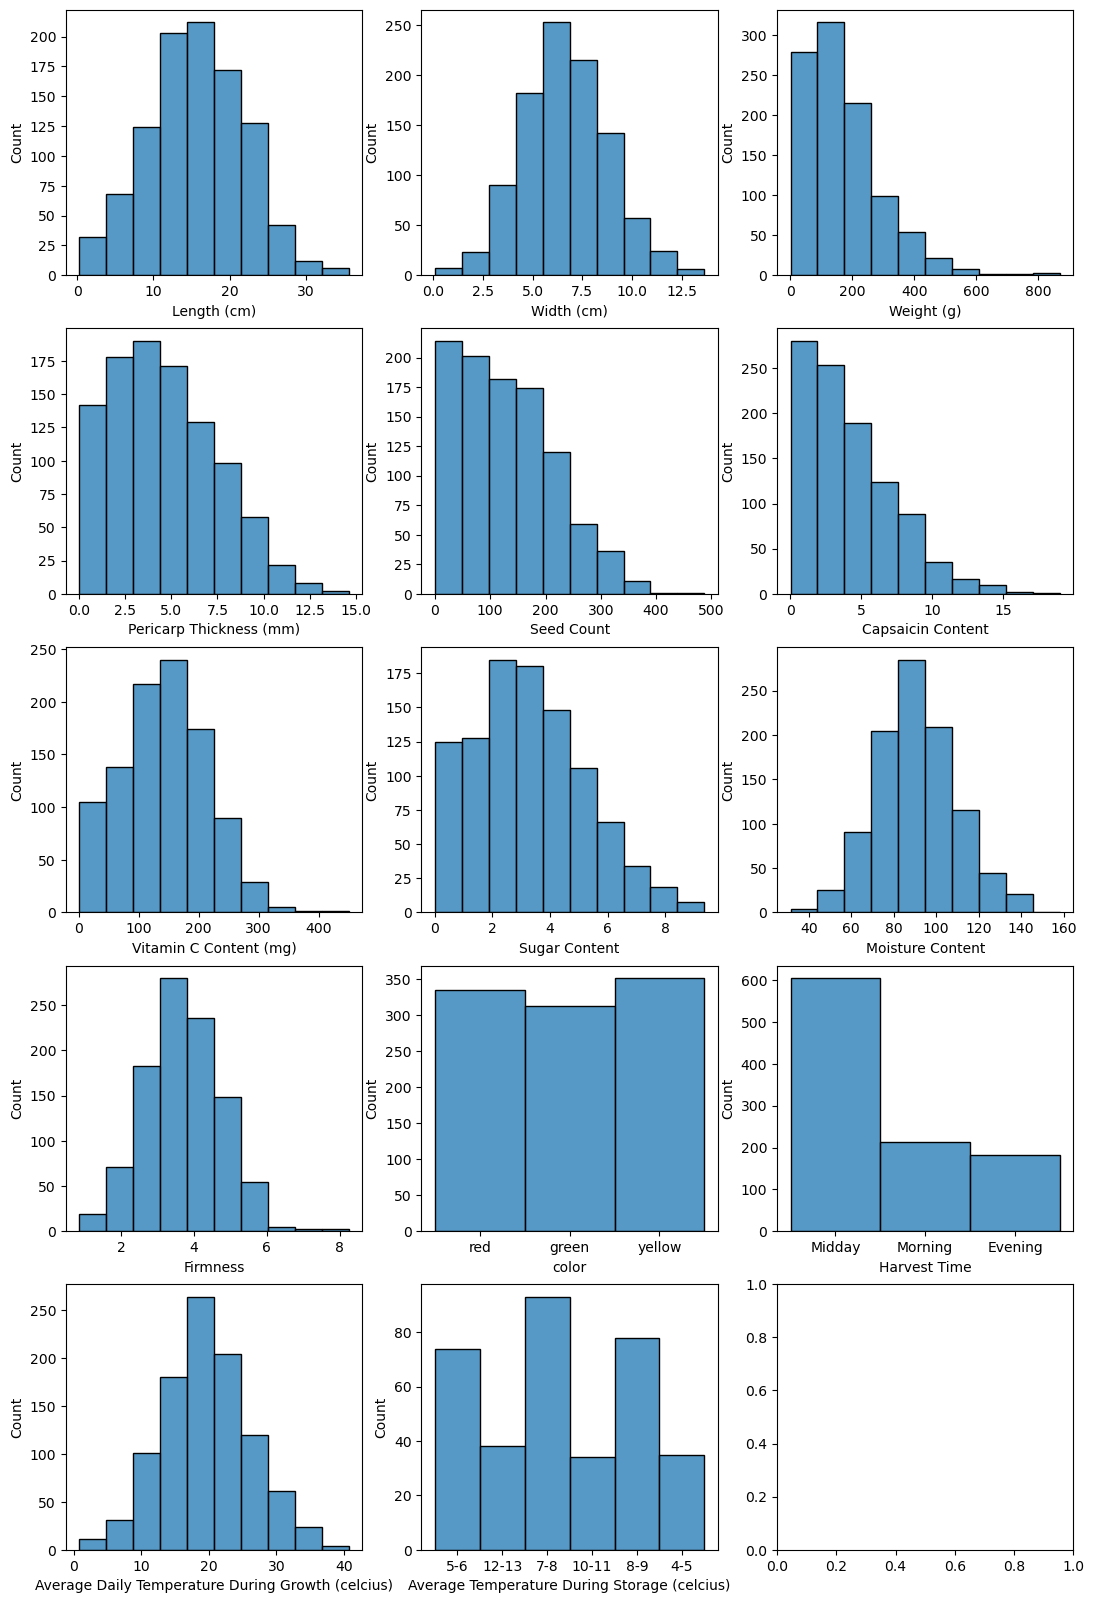

In [4]:
# A histogram plots of all features
fig, axes = plt.subplots(5,3,figsize=(13,20))
target_column = 'Scoville Heat Units (SHU)'

for i, col in enumerate(data):
    # Don't plot edible because it is the target
    if col != target_column:
        sns.histplot(data=data[col], ax=axes[i // 3][i % 3], bins=10)

We see that there aren't any outliers so there aren't many outliers from the figures there is no need for outliers removal.

In [5]:
# Finding out if we have empty data
data.isnull().sum()

Length (cm)                                            1
Width (cm)                                             1
Weight (g)                                             1
Pericarp Thickness (mm)                                2
Seed Count                                             1
Capsaicin Content                                      1
Vitamin C Content (mg)                                 0
Sugar Content                                          1
Moisture Content                                       0
Firmness                                               1
color                                                  1
Harvest Time                                           0
Average Daily Temperature During Growth (celcius)      0
Average Temperature During Storage (celcius)         648
Scoville Heat Units (SHU)                              0
dtype: int64

In [6]:
# Test data
data.isnull().sum()

Length (cm)                                            1
Width (cm)                                             1
Weight (g)                                             1
Pericarp Thickness (mm)                                2
Seed Count                                             1
Capsaicin Content                                      1
Vitamin C Content (mg)                                 0
Sugar Content                                          1
Moisture Content                                       0
Firmness                                               1
color                                                  1
Harvest Time                                           0
Average Daily Temperature During Growth (celcius)      0
Average Temperature During Storage (celcius)         648
Scoville Heat Units (SHU)                              0
dtype: int64

We see that there are missing many values, so we will just replace them with 0 in preprocessing.

### Data preprocessing and visualisation

In [7]:
def one_encode(df, feature):
    uniques = df[feature].unique()

    for value in uniques:
        df[f"{feature}_{value}"] = np.where(df[feature] == value, 1, 0)

In [8]:
def prepprocess(df):
    # Encoding all categories.
    one_encode(df, "color")
    one_encode(df, "Harvest Time")
    one_encode(df,'Average Temperature During Storage (celcius)')
    # Replacing missing valeus with zero.
    df.fillna(0, inplace=True)

def drop_outliers(df):
    z_scores = (df - df.mean()) / df.std()
    # Removing outliers, by using the z-score, by deleting all those that are more than 3 std
    df[np.abs(z_scores) < 3].dropna(inplace=True)

In [9]:
prepprocess(data)
prepprocess(test_data)

In [10]:
print("\n".join(data.columns))

Length (cm)
Width (cm)
Weight (g)
Pericarp Thickness (mm)
Seed Count
Capsaicin Content
Vitamin C Content (mg)
Sugar Content
Moisture Content
Firmness
color
Harvest Time
Average Daily Temperature During Growth (celcius)
Average Temperature During Storage (celcius)
Scoville Heat Units (SHU)
color_red
color_green
color_yellow
color_nan
Harvest Time_Midday
Harvest Time_Morning
Harvest Time_Evening
Average Temperature During Storage (celcius)_5-6
Average Temperature During Storage (celcius)_nan
Average Temperature During Storage (celcius)_12-13
Average Temperature During Storage (celcius)_7-8
Average Temperature During Storage (celcius)_10-11
Average Temperature During Storage (celcius)_8-9
Average Temperature During Storage (celcius)_4-5


### Modelling

In [11]:
### This cell treis many different classifiers, features, etc... trying to fidning the best classifier
### Please note that this cell has been modified alot in order to find the best classifier.

# We will try different models here and pick the best one
classifiers = [
    (LinearRegression, dict()),
]

pca_n_components = [1, 2, 3, 4]
polynomial_degrees = [2, 4, 6]

# Please note that I've tried many more features combination but removed them to make the coimputation faster
features = [
   ['Seed Count', 'Capsaicin Content', 'Pericarp Thickness (mm)', 'Moisture Content', 'Firmness', 'Sugar Content', 'Vitamin C Content (mg)'],
   ['Seed Count', 'Capsaicin Content', 'Pericarp Thickness (mm)', 'Moisture Content', 'Firmness', 'Sugar Content', 'Vitamin C Content (mg)', 'Length (cm)'],

]

def find_accuracies(df):
    best_classifier_score = float('-inf')
    best_classifier = None
    best_is_data_scaled = False
    best_is_pca = False
    best_is_polynomial = False
    best_feautres = []
    best_hyperparameters = {}

    for classifier_type, all_hyperparameters in classifiers:
        for feature_type in features:
            current_df = df[feature_type + [target_column]].copy()
            drop_outliers(current_df)

            pipeline_scaling = Pipeline([('scaler', StandardScaler()), ('classifier', classifier_type())])
            clf1 = GridSearchCV(pipeline_scaling, all_hyperparameters, scoring="neg_mean_absolute_error", n_jobs=-1)
            clf1.fit(current_df[feature_type], current_df[target_column])
            if clf1.best_score_ > best_classifier_score:
                best_classifier_score = clf1.best_score_
                best_classifier = classifier_type
                best_is_data_scaled = True
                best_is_pca = False
                best_is_polynomial = False
                best_feautres = feature_type
                best_hyperparameters = clf1.best_params_
            
            pipeline_pca = Pipeline([('pca', PCA()), ('classifier', classifier_type())])
            copy_dict = dict(all_hyperparameters)
            copy_dict['pca__n_components'] = pca_n_components
            clf2 = GridSearchCV(pipeline_pca, copy_dict, scoring="neg_mean_absolute_error", n_jobs=-1)
            clf2.fit(current_df[feature_type], current_df[target_column])

            if clf2.best_score_ > best_classifier_score:
                best_classifier_score = clf2.best_score_
                best_classifier = classifier_type
                best_is_data_scaled = False
                best_is_pca = True
                best_is_polynomial = False
                best_feautres = feature_type
                best_hyperparameters = clf2.best_params_
            
            pipeline_poly = Pipeline([('PolynomialFeatures', PolynomialFeatures()), ('classifier', classifier_type())])
            copy_dict = dict(all_hyperparameters)
            copy_dict['PolynomialFeatures__degree'] = polynomial_degrees
            clf3 = GridSearchCV(pipeline_poly, copy_dict, scoring="neg_mean_absolute_error", n_jobs=-1)
            clf3.fit(current_df[feature_type], current_df[target_column])
            
            if clf3.best_score_ > best_classifier_score:
                best_classifier_score = clf3.best_score_
                best_classifier = classifier_type
                best_is_data_scaled = False
                best_is_pca = False
                best_is_polynomial = True
                best_feautres = feature_type
                best_hyperparameters = clf3.best_params_

        # Printing with each for loop
        print()
        print('-' * 80)
        print('Classifiers ' + str(best_classifier))
        print('Hyperparameters ' + str(best_hyperparameters))
        print('Features ' + str(best_feautres))
        print('Is data scaled ' + str(best_is_data_scaled))
        print('Is PCA ' + str(best_is_pca))
        print('Is Polynomial ' + str(best_is_polynomial))
        print('Accuracy ' + str(best_classifier_score))
        print('-' * 80)
        print()

    return best_classifier, best_hyperparameters, best_feautres, best_is_data_scaled, best_is_pca, best_classifier_score

In [12]:
import warnings; warnings.simplefilter('ignore')  # Don't output warnings
find_accuracies(data)


--------------------------------------------------------------------------------
Classifiers <class 'sklearn.linear_model._base.LinearRegression'>
Hyperparameters {}
Features ['Seed Count', 'Capsaicin Content', 'Pericarp Thickness (mm)', 'Moisture Content', 'Firmness', 'Sugar Content', 'Vitamin C Content (mg)', 'Length (cm)']
Is data scaled True
Is PCA False
Is Polynomial False
Accuracy -68032.4299787361
--------------------------------------------------------------------------------



(sklearn.linear_model._base.LinearRegression,
 {},
 ['Seed Count',
  'Capsaicin Content',
  'Pericarp Thickness (mm)',
  'Moisture Content',
  'Firmness',
  'Sugar Content',
  'Vitamin C Content (mg)',
  'Length (cm)'],
 True,
 False,
 -68032.4299787361)

In [13]:
discrete_classifiers = [
    (RandomForestClassifier, {
        'classifier__n_estimators': [100, 500, 1000, 1500, 2000]
    })
]
bins = [5, 10, 15, 20]

def find_accuracies_discrete(df):
    best_classifier_score = float('-inf')
    best_classifier = None
    best_feautres = []
    best_hyperparameters = {}
    best_bins = 0

    for classifier_type, all_hyperparameters in discrete_classifiers:
        for feature_type in features:
            for num_bin in bins:
                current_df = df[feature_type + [target_column]].copy()
                drop_outliers(current_df)

                current_df[target_column] = pd.qcut(current_df[target_column], num_bin, duplicates='drop', labels=False)

                pipeline_scaling = Pipeline([('classifier', classifier_type())])
                clf1 = GridSearchCV(pipeline_scaling, all_hyperparameters, scoring="neg_mean_absolute_error", n_jobs=-1)
                clf1.fit(current_df[feature_type], current_df[target_column])
                if clf1.best_score_ > best_classifier_score:
                    best_classifier_score = clf1.best_score_
                    best_classifier = classifier_type
                    best_feautres = feature_type
                    best_hyperparameters = clf1.best_params_
                    best_bins = num_bin

        # Printing with each for loop
        print()
        print('-' * 80)
        print('Classifiers ' + str(best_classifier))
        print('Hyperparameters ' + str(best_hyperparameters))
        print('bins ' + str(best_bins))
        print('Features ' + str(best_feautres))
        print('Accuracy ' + str(best_classifier_score))
        print('-' * 80)
        print()

    return best_classifier, best_hyperparameters, best_feautres, best_classifier_score

In [14]:
import warnings; warnings.simplefilter('ignore')  # Don't output warnings
find_accuracies_discrete(data)


--------------------------------------------------------------------------------
Classifiers <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Hyperparameters {'classifier__n_estimators': 100}
bins 5
Features ['Seed Count', 'Capsaicin Content', 'Pericarp Thickness (mm)', 'Moisture Content', 'Firmness', 'Sugar Content', 'Vitamin C Content (mg)', 'Length (cm)']
Accuracy -0.446
--------------------------------------------------------------------------------



(sklearn.ensemble._forest.RandomForestClassifier,
 {'classifier__n_estimators': 100},
 ['Seed Count',
  'Capsaicin Content',
  'Pericarp Thickness (mm)',
  'Moisture Content',
  'Firmness',
  'Sugar Content',
  'Vitamin C Content (mg)',
  'Length (cm)'],
 -0.446)

### Final evaluation

In [18]:
# This is the best classifier (uses bins) and can be found in best_classifier.py
best_pipeline = Pipeline([('classifier', RandomForestClassifier(n_estimators=100))])
best_features = ['Seed Count', 'Capsaicin Content', 'Pericarp Thickness (mm)', 'Moisture Content', 'Firmness', 'Sugar Content', 'Vitamin C Content (mg)', 'Length (cm)']
best_num_bins = 5
current_df = data[best_features + [target_column]].copy()
drop_outliers(current_df)
new_target, bin_edges = pd.qcut(current_df[target_column], best_num_bins, duplicates='drop', labels=False, retbins=True)
current_df[target_column] = new_target
best_pipeline.fit(current_df[best_features], current_df[target_column])
predictions = best_pipeline.predict(test_data.fillna(0)[best_features])

# Transforming bins back to numbers
for i in range(len(bin_edges)):
    predictions[predictions == i] = bin_edges[i]

df = pd.DataFrame(predictions, columns=[target_column])
df.index.name = 'index'
df.to_csv("predictions.csv")

In [16]:
# This the best linear regression classifier, it got 68305.71744 on Kaggle
best_pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', LinearRegression())])
best_features = ['Seed Count', 'Capsaicin Content', 'Pericarp Thickness (mm)', 'Moisture Content', 'Firmness', 'Sugar Content', 'Vitamin C Content (mg)', 'Length (cm)']
current_df = data[best_features + [target_column]].copy()
drop_outliers(current_df)
best_pipeline.fit(current_df[best_features], current_df[target_column])
predictions = best_pipeline.predict(test_data.fillna(0)[best_features])
df = pd.DataFrame(predictions, columns=[target_column])
df.index.name = 'index'
df.to_csv("predictions.csv")

### Kaggle submission